In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, precision_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
from sklearn.metrics import f1_score, roc_auc_score
from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import pearsonr

## Dataset loading - ucitavanje dataseta

In [133]:
df=pd.read_excel('../datasets/dataset2.xlsx')

## Display info about data and first five columns - prikaz informacija o datasetu i prvih 5 kolona iz dataseta

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   ime                      998 non-null    object
 1   dob                      998 non-null    int64 
 2   trudnoca_po_redu         998 non-null    object
 3   tetanus_vakcina_po_redu  998 non-null    object
 4   sedmica_trudnoce         998 non-null    object
 5   tezina                   998 non-null    object
 6   visina                   998 non-null    object
 7   krvni_pritisak           998 non-null    object
 8   anemija                  123 non-null    object
 9   zutica                   12 non-null     object
 10  polozaj_fetusa           998 non-null    object
 11  pokreti_fetusa           998 non-null    object
 12  otkucaji_srca_fetusa     998 non-null    object
 13  albumin_urin             134 non-null    object
 14  test_urina_za_dijabetes  998 non-null    o

In [135]:
df.head()

,ime,dob,trudnoca_po_redu,tetanus_vakcina_po_redu,sedmica_trudnoce,tezina,visina,krvni_pritisak,anemija,zutica,polozaj_fetusa,pokreti_fetusa,otkucaji_srca_fetusa,albumin_urin,test_urina_za_dijabetes,sifillis,hepatitisb,rizicna_trudnoca
0,Rituporna,18,1st,1st,38 week,50 kg,5.3'',100/60,NaN,NaN,Normal,Normal,140m,NaN,Yes,Negative,Negative,Yes
1,Moina,25,2nd,2nd,38 week,60 kg,5.2'',100/70,NaN,NaN,Normal,Normal,130m,NaN,Yes,Positive,Negative,No
2,Rabeya,20,1st,1st,30 week,55 kg,5.0'',100/60,NaN,NaN,Normal,Normal,120m,NaN,Yes,Negative,Negative,Yes
3,Shorna,22,1st,3rd,35 week,51 kg,5.4'',110/65,NaN,NaN,Normal,Normal,130m,NaN,Yes,Positive,Negative,Yes
4,Tania Akter,20,1st,2nd,30 week,53 kg,5.2'',100/55,NaN,NaN,Normal,Normal,125m,NaN,Yes,Negative,Negative,No


Histograms for numeric variable
Prikaz histograma za numeričku varijablu

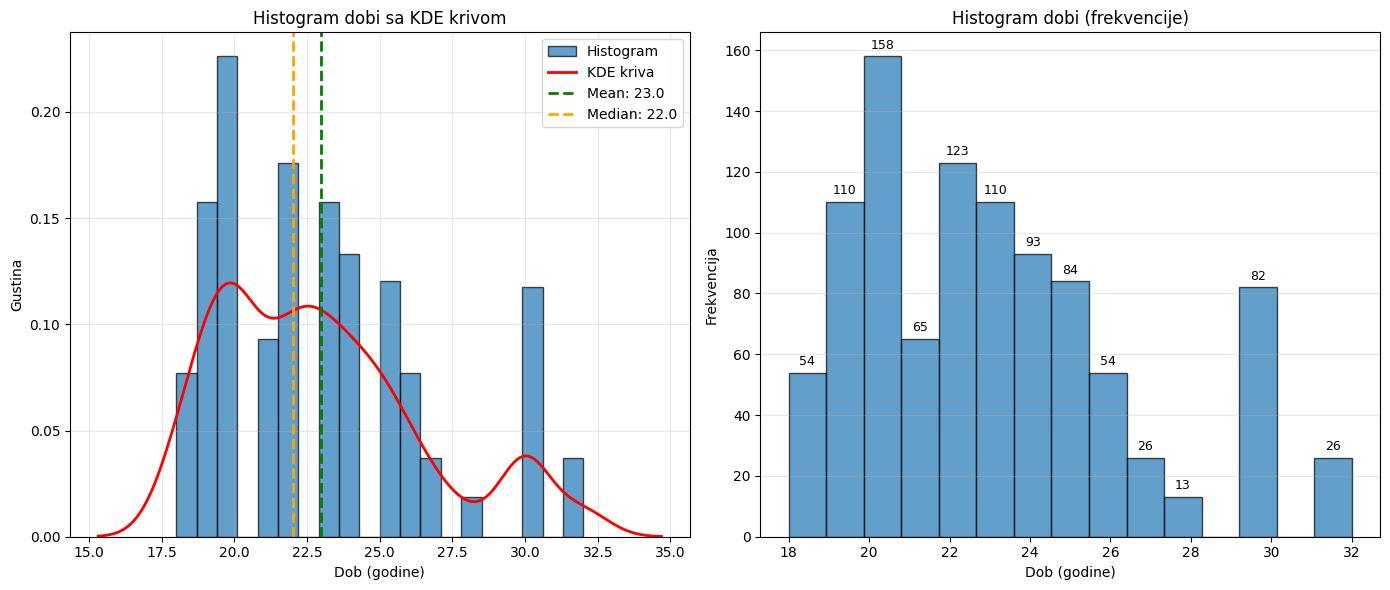

In [136]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram 1: Osnovni sa KDE
axes[0].hist(df['dob'], bins=20, edgecolor='black', alpha=0.7, density=True, label='Histogram')
sns.kdeplot(df['dob'], ax=axes[0], color='red', linewidth=2, label='KDE kriva')
axes[0].axvline(df['dob'].mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {df["dob"].mean():.1f}')
axes[0].axvline(df['dob'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {df["dob"].median():.1f}')
axes[0].set_xlabel('Dob (godine)')
axes[0].set_ylabel('Gustina')
axes[0].set_title('Histogram dobi sa KDE krivom')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram 2: Sa frekvencijama i statistikama
counts, bins, patches = axes[1].hist(df['dob'], bins=15, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Dob (godine)')
axes[1].set_ylabel('Frekvencija')
axes[1].set_title('Histogram dobi (frekvencije)')

# Dodavanje frekvencija na vrh stubića
for i, (count, bin_edge) in enumerate(zip(counts, bins[:-1])):
    if count > 0:
        axes[1].text(bin_edge + (bins[1]-bins[0])/2, count + max(counts)*0.01, 
                    f'{int(count)}', ha='center', va='bottom', fontsize=9)

axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Pie chart and bar chart for categorical variables ->


Prikaz "pie chart-a" i bar chart-a za kategoričke varijable

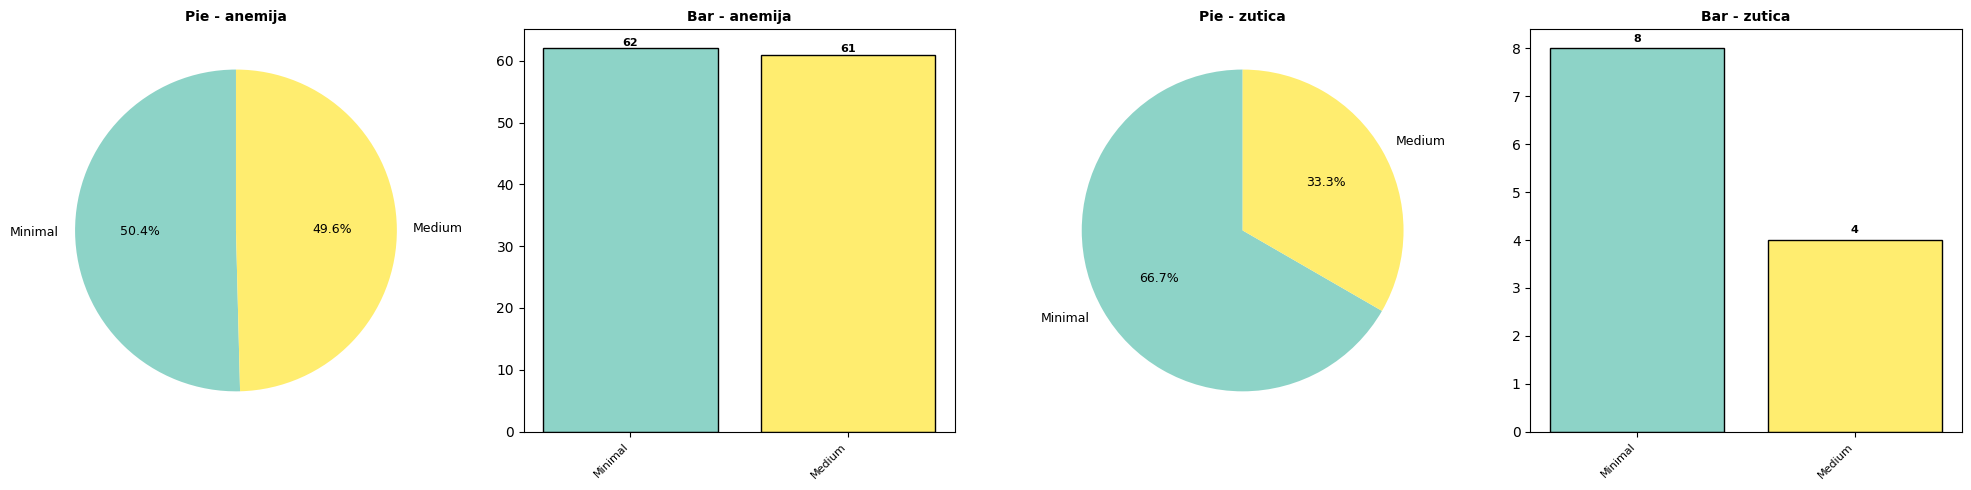

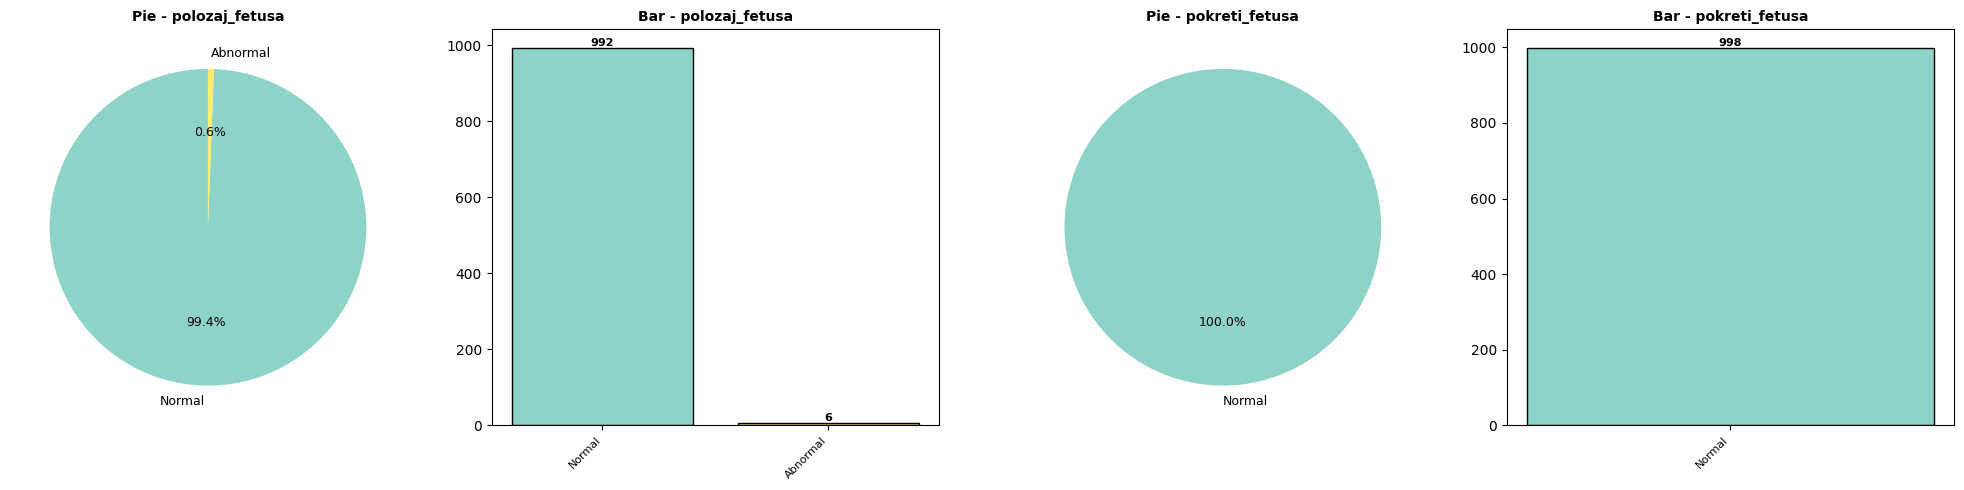

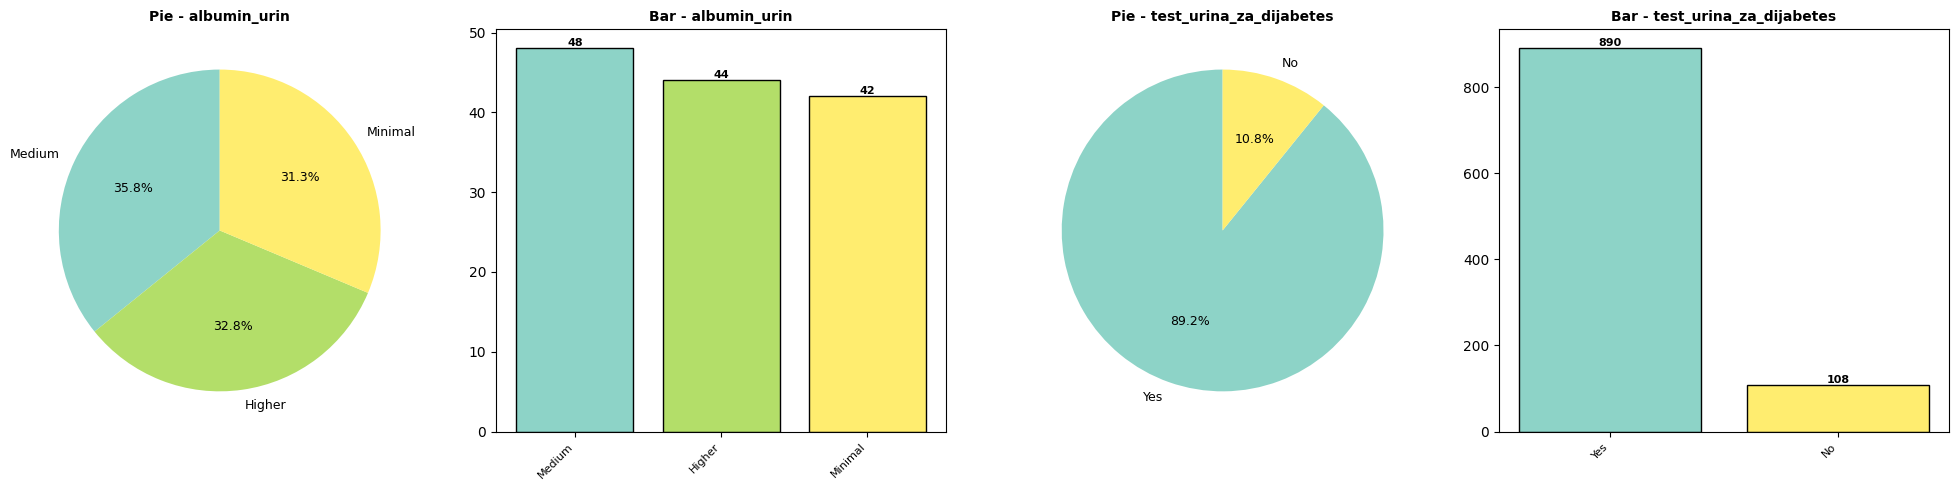

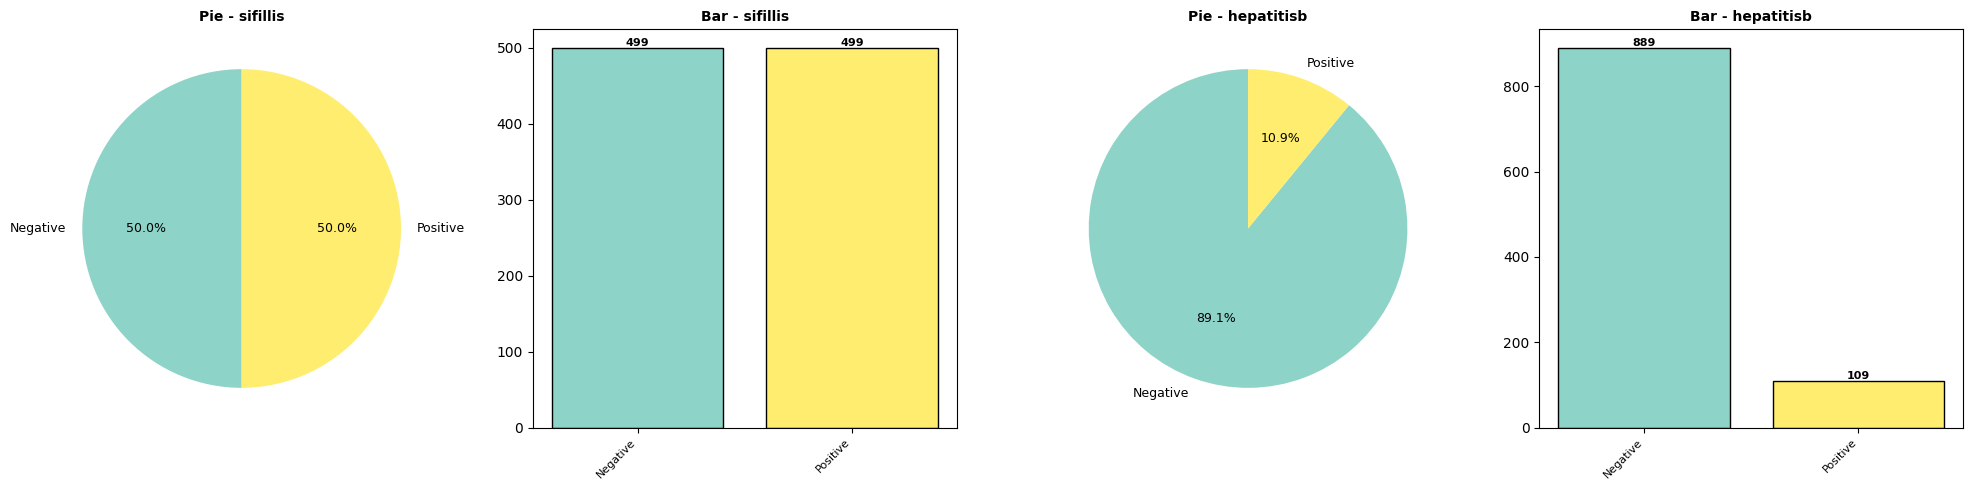

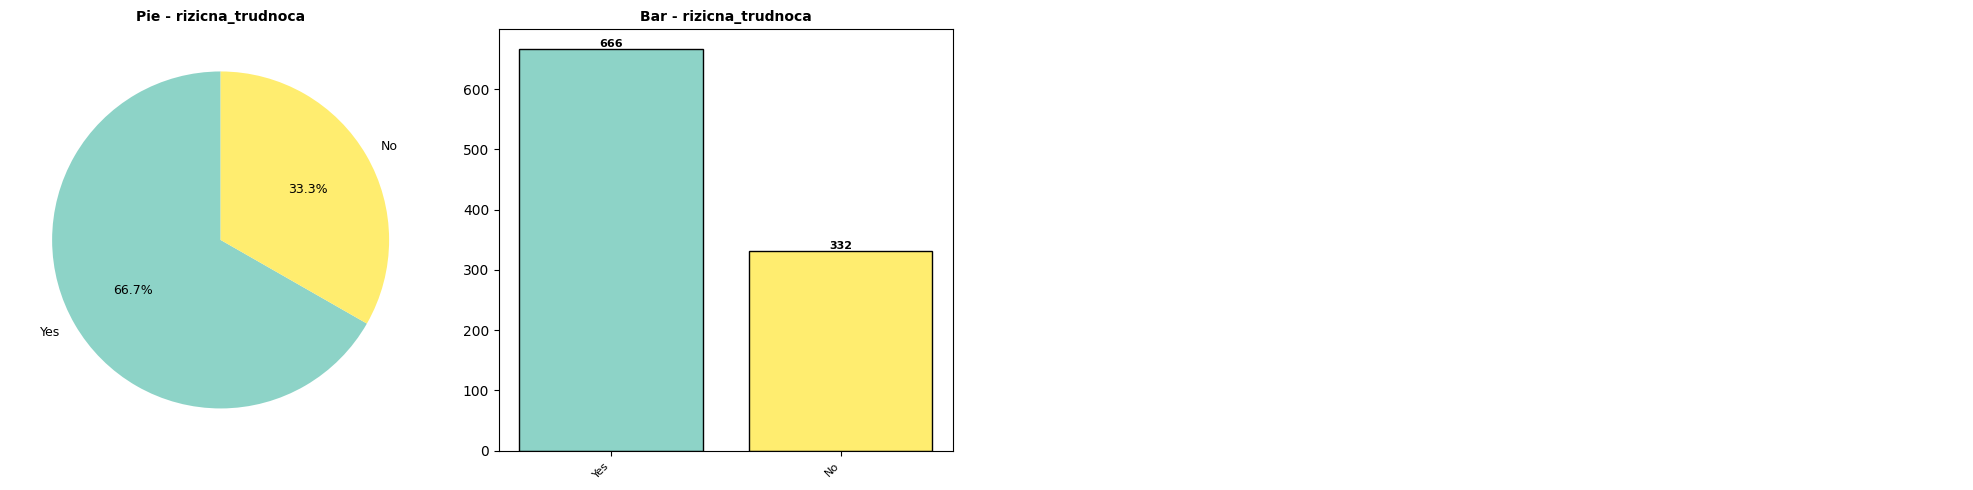

In [137]:
kategoricke_varijable = ['anemija', 'zutica', 'polozaj_fetusa', 'pokreti_fetusa', 
                         'albumin_urin', 'test_urina_za_dijabetes', 'sifillis', 
                         'hepatitisb', 'rizicna_trudnoca']

# Filtriramo samo one koje postoje u df
postojece_var = [v for v in kategoricke_varijable if v in df.columns]

# Prolazimo kroz varijable u koracima po 2 (da bismo ih uparili)
for i in range(0, len(postojece_var), 2):
    par = postojece_var[i:i+2]
    
    # Kreiramo figuru sa 1 redom i 4 kolone (2 za svaku varijablu)
    fig, axes = plt.subplots(1, 4, figsize=(20, 5)) 
    
    for idx, var in enumerate(par):
        podaci = df[var].dropna()
        if len(podaci) > 0:
            freq = podaci.value_counts()
            colors = plt.cm.Set3(np.linspace(0, 1, len(freq)))
            
            # Određujemo indekse za kolone (0,1 za prvu varijablu; 2,3 za drugu)
            col_pie = idx * 2
            col_bar = idx * 2 + 1
            
            # --- Pie Chart ---
            axes[col_pie].pie(freq.values, labels=freq.index, autopct='%1.1f%%', 
                              colors=colors, startangle=90, textprops={'fontsize': 9})
            axes[col_pie].set_title(f'Pie - {var}', fontsize=10, fontweight='bold')
            
            # --- Bar Chart ---
            bars = axes[col_bar].bar(range(len(freq)), freq.values, color=colors, edgecolor='black')
            axes[col_bar].set_xticks(range(len(freq)))
            axes[col_bar].set_xticklabels(freq.index, rotation=45, ha='right', fontsize=8)
            axes[col_bar].set_title(f'Bar - {var}', fontsize=10, fontweight='bold')
            
            # Dodavanje brojeva iznad stubića
            for bar, val in zip(bars, freq.values):
                axes[col_bar].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                                   str(val), ha='center', va='bottom', fontsize=8, fontweight='bold')

    # Ako je ostala samo jedna varijabla u zadnjem redu, sakrij prazne grafove
    if len(par) < 2:
        axes[2].axis('off')
        axes[3].axis('off')

    plt.tight_layout()
    plt.show()

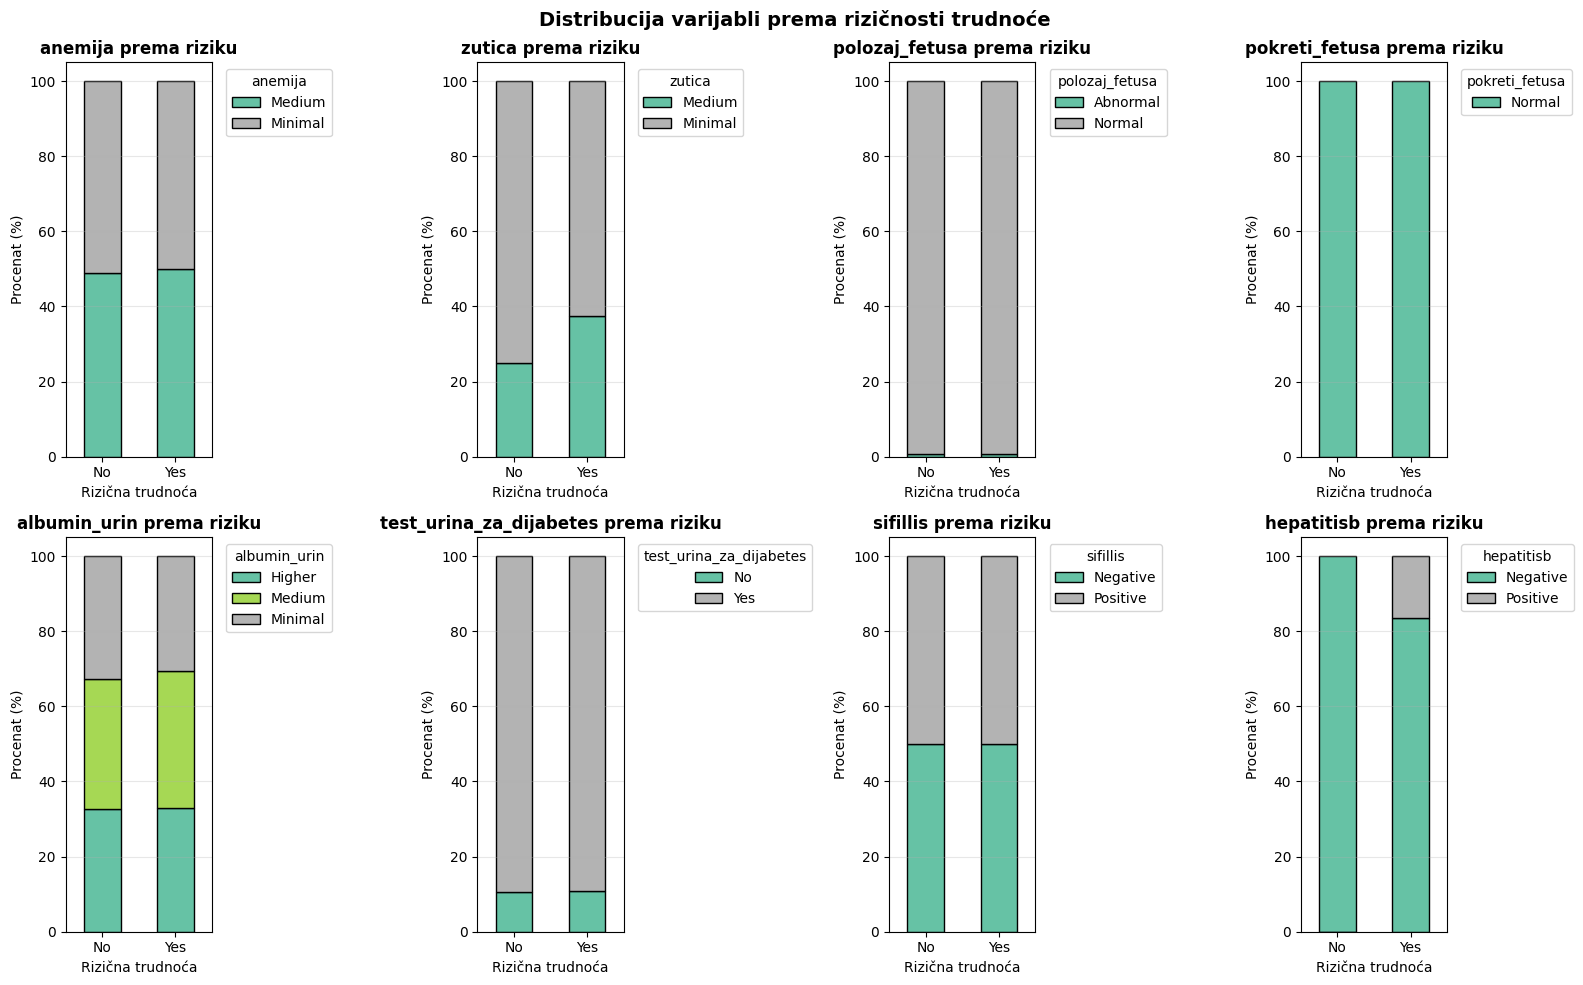

In [138]:
if 'rizicna_trudnoca' in df.columns:
    # Analiza po rizičnosti trudnoće
    fig, axes = plt.subplots(2, 4, figsize=(16, 10))
    axes = axes.flatten()
    
    for idx, var in enumerate(kategoricke_varijable):
        if var != 'rizicna_trudnoca' and idx < len(axes):
            # Kreiraj kontingencijsku tabelu
            crosstab = pd.crosstab(df['rizicna_trudnoca'], df[var], normalize='index') * 100
            
            # Stacked bar chart
            crosstab.plot(kind='bar', stacked=True, ax=axes[idx], 
                         colormap='Set2', edgecolor='black')
            axes[idx].set_title(f'{var} prema riziku', fontweight='bold')
            axes[idx].set_xlabel('Rizična trudnoća')
            axes[idx].set_ylabel('Procenat (%)')
            axes[idx].legend(title=var, bbox_to_anchor=(1.05, 1), loc='upper left')
            axes[idx].grid(True, alpha=0.3, axis='y')
            axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=0)
    
    # Sakrij višak subplotova
    for idx in range(len(kategoricke_varijable)-1, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Distribucija varijabli prema rizičnosti trudnoće', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Descriptive statistic - Deskriptivna statistika

In [139]:
df.describe()

,dob
count,998.000000
mean,22.962926
std,3.568168
min,18.000000
25%,20.000000
50%,22.000000
75%,25.000000
max,32.000000


### Displaying the missing values for each variable in dataset
### Prikaz nedostajućih vrijednosti za svaku varijablu u datasetu

In [140]:
print(df.isnull().sum()) 

ime                          0
dob                          0
trudnoca_po_redu             0
tetanus_vakcina_po_redu      0
sedmica_trudnoce             0
tezina                       0
visina                       0
krvni_pritisak               0
anemija                    875
zutica                     986
polozaj_fetusa               0
pokreti_fetusa               0
otkucaji_srca_fetusa         0
albumin_urin               864
test_urina_za_dijabetes      0
sifillis                     0
hepatitisb                   0
rizicna_trudnoca             0
dtype: int64


## Filling the missing values of categorocial variables with mode
## Popunjavanje nedostajućih vrijednosti za kategoričke varijable korištenjem mode vrijednosti

In [141]:
df['anemija'].unique()

array([nan, 'Minimal', 'Medium'], dtype=object)

In [142]:
print(df['anemija'].value_counts(dropna=False))

anemija
NaN        875
Minimal     62
Medium      61
Name: count, dtype: int64


In [143]:
df['zutica'].unique()

array([nan, 'Minimal', 'Medium'], dtype=object)

In [144]:
print(df['zutica'].value_counts(dropna=False))

zutica
NaN        986
Minimal      8
Medium       4
Name: count, dtype: int64


In [145]:
df['albumin_urin'].unique()

array([nan, 'Higher', 'Minimal', 'Medium'], dtype=object)

In [146]:
print(df['albumin_urin'].value_counts(dropna=False))

albumin_urin
NaN        864
Medium      48
Higher      44
Minimal     42
Name: count, dtype: int64


In [147]:
df['anemija'] = df['anemija'].fillna('None')
df['albumin_urin'] = df['albumin_urin'].fillna('Normal')

In [148]:
df['anemija'].unique()

array(['None', 'Minimal', 'Medium'], dtype=object)

#### Droping column "zutica" since we have a 98% of missing values in dataset
#### Brisanje kolone "zutica" obzirom da postoji preko 98% nedostajućih vrijednosti u dataset-u

In [149]:
df.drop(columns=['zutica'], inplace=True)

In [150]:
print(df.isnull().sum()) 

ime                        0
dob                        0
trudnoca_po_redu           0
tetanus_vakcina_po_redu    0
sedmica_trudnoce           0
tezina                     0
visina                     0
krvni_pritisak             0
anemija                    0
polozaj_fetusa             0
pokreti_fetusa             0
otkucaji_srca_fetusa       0
albumin_urin               0
test_urina_za_dijabetes    0
sifillis                   0
hepatitisb                 0
rizicna_trudnoca           0
dtype: int64


Removing unnecessary column -> 
Uklanjanje kolone koja neće značiti tokom same analize

In [151]:
df.drop(columns = ['ime'], inplace=True)

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   dob                      998 non-null    int64 
 1   trudnoca_po_redu         998 non-null    object
 2   tetanus_vakcina_po_redu  998 non-null    object
 3   sedmica_trudnoce         998 non-null    object
 4   tezina                   998 non-null    object
 5   visina                   998 non-null    object
 6   krvni_pritisak           998 non-null    object
 7   anemija                  998 non-null    object
 8   polozaj_fetusa           998 non-null    object
 9   pokreti_fetusa           998 non-null    object
 10  otkucaji_srca_fetusa     998 non-null    object
 11  albumin_urin             998 non-null    object
 12  test_urina_za_dijabetes  998 non-null    object
 13  sifillis                 998 non-null    object
 14  hepatitisb               998 non-null    o

Converting categorical variables into numerical ->
Pretvaranje kategoričkih varijabli u numeričke

In [153]:
df['trudnoca_po_redu'].unique()

array(['1st', '2nd', '3rd'], dtype=object)

In [154]:
df['trudnoca_po_redu'] = df['trudnoca_po_redu'].map({'1st': 1, '2nd': 2, '3rd': 3})

In [155]:
print(df['trudnoca_po_redu'].dtype)

int64


In [156]:
df['tetanus_vakcina_po_redu'].unique()

array(['1st', '2nd', '3rd'], dtype=object)

In [157]:
df['tetanus_vakcina_po_redu'] = df['tetanus_vakcina_po_redu'].map({'1st': 1, '2nd': 2, '3rd': 3})

In [158]:
print(df['tetanus_vakcina_po_redu'].dtype)

int64


In [159]:
df['sedmica_trudnoce'].unique()

array(['38 week', '30 week', '35 week', '20 week', '23 week', '28 week',
       '25 week', '32 week', '26 week', '24 week', '36 week'],
      dtype=object)

In [160]:
df['sedmica_trudnoce'] = df['sedmica_trudnoce'].str.extract(r'(\d+)').astype(int)

In [161]:
print(df['sedmica_trudnoce'].dtype)

int64


In [162]:
df['tezina'].unique()

array(['50 kg', '60 kg', '55 kg', '51 kg', '53 kg', '61 kg', '52 kg',
       '62 kg', '58 kg', '56 kg', '65 kg', '49 kg', '45 kg', '63 kg'],
      dtype=object)

In [163]:
df['tezina'] = df['tezina'].astype(str).str.extract(r'(\d+)').astype(int)

In [164]:
print(df['tezina'].dtype)

int64


### Converting height from feets to cm
### Konverzija visine koja je izražena u feets u cm

In [165]:
df['visina'] = df['visina'].astype(str).str.replace("''", "", regex=False).astype(float)

df['visina'] = df['visina'] * 30.48

df['visina'] = df['visina'].round(0).astype(int)

In [166]:
print(df['visina'].dtype)

int64


### Seperating the value of blood preasure into two different columns: systolic and diastolic preassure
### Razdvajanje varijable krvni pritisak u dvije zasebne: donji krvni pritisak i gornji krvni pritisak

In [167]:
df[['sistolicki_krvni_tlak', 'dijastolicki_krvni_tlak']] = df['krvni_pritisak'].str.split('/', expand=True)

df['sistolicki_krvni_tlak'] = df['sistolicki_krvni_tlak'].astype(int)
df['dijastolicki_krvni_tlak'] = df['dijastolicki_krvni_tlak'].astype(int)

### Droping the original column for blood preasure since we now have a new variables
### Brisanje originalne kolone krvni pritisak obzirom da sada imamo dvije zasebne varijable

In [168]:
df.drop(columns=['krvni_pritisak'], inplace=True)

In [169]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   dob                      998 non-null    int64 
 1   trudnoca_po_redu         998 non-null    int64 
 2   tetanus_vakcina_po_redu  998 non-null    int64 
 3   sedmica_trudnoce         998 non-null    int64 
 4   tezina                   998 non-null    int64 
 5   visina                   998 non-null    int64 
 6   anemija                  998 non-null    object
 7   polozaj_fetusa           998 non-null    object
 8   pokreti_fetusa           998 non-null    object
 9   otkucaji_srca_fetusa     998 non-null    object
 10  albumin_urin             998 non-null    object
 11  test_urina_za_dijabetes  998 non-null    object
 12  sifillis                 998 non-null    object
 13  hepatitisb               998 non-null    object
 14  rizicna_trudnoca         998 non-null    o

Categorical variables to numerical - PART 2

In [170]:
varijable = ['anemija', 'polozaj_fetusa', 'pokreti_fetusa', 
             'otkucaji_srca_fetusa', 'albumin_urin', 'test_urina_za_dijabetes', 
             'sifillis', 'hepatitisb', 'rizicna_trudnoca']

for var in varijable:
    print(f"\n--- Unikatne vrednosti za '{var}': ---")
    unique_values = df[var].unique()
    print(unique_values)
    
    print(f"Broj unikatnih vrednosti: {len(unique_values)}")


--- Unikatne vrednosti za 'anemija': ---
['None' 'Minimal' 'Medium']
Broj unikatnih vrednosti: 3

--- Unikatne vrednosti za 'polozaj_fetusa': ---
['Normal' 'Abnormal']
Broj unikatnih vrednosti: 2

--- Unikatne vrednosti za 'pokreti_fetusa': ---
['Normal']
Broj unikatnih vrednosti: 1

--- Unikatne vrednosti za 'otkucaji_srca_fetusa': ---
['140m' '130m' '120m' '125m' '150m']
Broj unikatnih vrednosti: 5

--- Unikatne vrednosti za 'albumin_urin': ---
['Normal' 'Higher' 'Minimal' 'Medium']
Broj unikatnih vrednosti: 4

--- Unikatne vrednosti za 'test_urina_za_dijabetes': ---
['Yes' 'No']
Broj unikatnih vrednosti: 2

--- Unikatne vrednosti za 'sifillis': ---
['Negative' 'Positive']
Broj unikatnih vrednosti: 2

--- Unikatne vrednosti za 'hepatitisb': ---
['Negative' 'Positive']
Broj unikatnih vrednosti: 2

--- Unikatne vrednosti za 'rizicna_trudnoca': ---
['Yes' 'No']
Broj unikatnih vrednosti: 2


Since the variable "pokreti_fetusa" has only one unique value, this column is going to be delete



Obzirom da varijabla "pokreti_fetusa" ima samo jednu jedinstvenu vrijednost, u nastavku će biti obrisana

In [171]:
df.drop(columns=['pokreti_fetusa'],inplace=True)

In [172]:
df['polozaj_fetusa'].describe()

count        998
unique         2
top       Normal
freq         992
Name: polozaj_fetusa, dtype: object

In [173]:
varijable = ['anemija', 'polozaj_fetusa', 
             'otkucaji_srca_fetusa', 'albumin_urin', 'test_urina_za_dijabetes', 
             'sifillis', 'hepatitisb', 'rizicna_trudnoca']

for var in varijable:
    print(f"\n--- Unikatne vrednosti za '{var}': ---")
    unique_values = df[var].describe()
    print(unique_values)


--- Unikatne vrednosti za 'anemija': ---
count      998
unique       3
top       None
freq       875
Name: anemija, dtype: object

--- Unikatne vrednosti za 'polozaj_fetusa': ---
count        998
unique         2
top       Normal
freq         992
Name: polozaj_fetusa, dtype: object

--- Unikatne vrednosti za 'otkucaji_srca_fetusa': ---
count      998
unique       5
top       130m
freq       363
Name: otkucaji_srca_fetusa, dtype: object

--- Unikatne vrednosti za 'albumin_urin': ---
count        998
unique         4
top       Normal
freq         864
Name: albumin_urin, dtype: object

--- Unikatne vrednosti za 'test_urina_za_dijabetes': ---
count     998
unique      2
top       Yes
freq      890
Name: test_urina_za_dijabetes, dtype: object

--- Unikatne vrednosti za 'sifillis': ---
count          998
unique           2
top       Negative
freq           499
Name: sifillis, dtype: object

--- Unikatne vrednosti za 'hepatitisb': ---
count          998
unique           2
top       Negative


Analyzing the correlation between variables "sedmica_trudnoce" and "polozaj_fetusa"


Analiza povezanosti varijabli "sedmica_trudnoce" i "polozaj_fetusa"

In [174]:
    # 1. Ukrštena tabela (crosstab)
    cross_tab = pd.crosstab(df['sedmica_trudnoce'], df['polozaj_fetusa'], margins=True)
    print("Ukrštena tabela - položaj fetusa po sedmicama:")
    print(cross_tab)
    
    # 2. Procenti po sedmicama
    cross_tab_percent = pd.crosstab(df['sedmica_trudnoce'], df['polozaj_fetusa'], normalize='index') * 100
    print("\nProcenat normalnog položaja po sedmicama:")
    print(cross_tab_percent)

Ukrštena tabela - položaj fetusa po sedmicama:
polozaj_fetusa    Abnormal  Normal  All
sedmica_trudnoce                       
20                       1      60   61
23                       0      79   79
24                       0      78   78
25                       0     118  118
26                       0      60   60
28                       0      59   59
30                       3     241  244
32                       0      59   59
35                       2     156  158
36                       0      22   22
38                       0      60   60
All                      6     992  998

Procenat normalnog položaja po sedmicama:
polozaj_fetusa    Abnormal      Normal
sedmica_trudnoce                      
20                1.639344   98.360656
23                0.000000  100.000000
24                0.000000  100.000000
25                0.000000  100.000000
26                0.000000  100.000000
28                0.000000  100.000000
30                1.229508   98.770492

Converting "otkucaji_srca_fetusa" into numeric variable
Pretvaranje "otkucaji_srca_fetusa" u numeričku vrijednost

In [175]:
df['otkucaji_srca_fetusa'] = df['otkucaji_srca_fetusa'].astype(str).str.extract(r'(\d+)').astype(int)

Converting remaining variables into numeric type -> Pretvaranje preostalih kategoričkih varijabli u numeričke tipove

In [176]:
df['test_urina_za_dijabetes'] = df['test_urina_za_dijabetes'].map({'Yes': 1, 'No': 0})
df['sifillis'] = df['sifillis'].map({'Positive': 1, 'Negative': 0})
df['hepatitisb'] = df['hepatitisb'].map({'Positive': 1, 'Negative': 0})
df['rizicna_trudnoca'] = df['rizicna_trudnoca'].map({'Yes': 1, 'No': 0})
df['albumin_urin'] = df['albumin_urin'].map({'Normal': 0, 'Minimal': 1, 'Medium': 2, 'Higher': 3})


In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   dob                      998 non-null    int64 
 1   trudnoca_po_redu         998 non-null    int64 
 2   tetanus_vakcina_po_redu  998 non-null    int64 
 3   sedmica_trudnoce         998 non-null    int64 
 4   tezina                   998 non-null    int64 
 5   visina                   998 non-null    int64 
 6   anemija                  998 non-null    object
 7   polozaj_fetusa           998 non-null    object
 8   otkucaji_srca_fetusa     998 non-null    int64 
 9   albumin_urin             998 non-null    int64 
 10  test_urina_za_dijabetes  998 non-null    int64 
 11  sifillis                 998 non-null    int64 
 12  hepatitisb               998 non-null    int64 
 13  rizicna_trudnoca         998 non-null    int64 
 14  sistolicki_krvni_tlak    998 non-null    i

In [178]:
df['dob'].min(), df['dob'].max(), df['dob'].mean(), df['dob'].median(), df['dob'].std()

(np.int64(18),
 np.int64(32),
 np.float64(22.962925851703407),
 np.float64(22.0),
 np.float64(3.568168119315024))

In [179]:
print(df['anemija'].dtype)
print(df['polozaj_fetusa'].dtype)

object
object


In [180]:
df['anemija'].unique()

array(['None', 'Minimal', 'Medium'], dtype=object)

In [181]:
df['anemija'] = df['anemija'].map({'None': 0, 'Minimal': 1, 'Medium': 2})
df['polozaj_fetusa'] = df['polozaj_fetusa'].map({'Normal': 0, 'Abnormal': 1})

In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   dob                      998 non-null    int64
 1   trudnoca_po_redu         998 non-null    int64
 2   tetanus_vakcina_po_redu  998 non-null    int64
 3   sedmica_trudnoce         998 non-null    int64
 4   tezina                   998 non-null    int64
 5   visina                   998 non-null    int64
 6   anemija                  998 non-null    int64
 7   polozaj_fetusa           998 non-null    int64
 8   otkucaji_srca_fetusa     998 non-null    int64
 9   albumin_urin             998 non-null    int64
 10  test_urina_za_dijabetes  998 non-null    int64
 11  sifillis                 998 non-null    int64
 12  hepatitisb               998 non-null    int64
 13  rizicna_trudnoca         998 non-null    int64
 14  sistolicki_krvni_tlak    998 non-null    int64
 15  dijast

Considering that new added columns "sistolicki_krvni_tlak" and "dijastolicki_krvni_tlak" are added at the end of the dataset, the target variable "rizicna_trudnoca" is moved to the end of the dataset

S obzirom da su novododane kolone "sistolicki_krvni_tlak" i "dijastolicki_krvni_tlak" dodane na kraj skupa podataka, ciljna varijabla "rizicna_trudnoca" je premještena na kraj skupa podataka.

In [183]:
last_three_columns = ['sistolicki_krvni_tlak', 'dijastolicki_krvni_tlak', 'rizicna_trudnoca']
remaining_columns = [col for col in df.columns if col not in last_three_columns]

new_order = remaining_columns + last_three_columns

df = df[new_order]

print(df.columns[-3:])

Index(['sistolicki_krvni_tlak', 'dijastolicki_krvni_tlak', 'rizicna_trudnoca'], dtype='object')


Correlation matrix

Korelacijska matrica

In [184]:
correlation_matrix = df.corr(method='pearson')
print(correlation_matrix)

                              dob  trudnoca_po_redu  tetanus_vakcina_po_redu  \
dob                      1.000000          0.196842                 0.025567   
trudnoca_po_redu         0.196842          1.000000                -0.003330   
tetanus_vakcina_po_redu  0.025567         -0.003330                 1.000000   
sedmica_trudnoce        -0.009801          0.020481                -0.002831   
tezina                   0.005466         -0.034752                 0.026803   
visina                   0.001781         -0.027589                 0.010412   
anemija                 -0.032920         -0.007989                 0.024223   
polozaj_fetusa          -0.002826          0.033682                 0.004935   
otkucaji_srca_fetusa     0.017213          0.013627                 0.008952   
albumin_urin             0.026707         -0.027514                -0.009349   
test_urina_za_dijabetes -0.018092          0.008063                 0.051069   
sifillis                 0.067149       

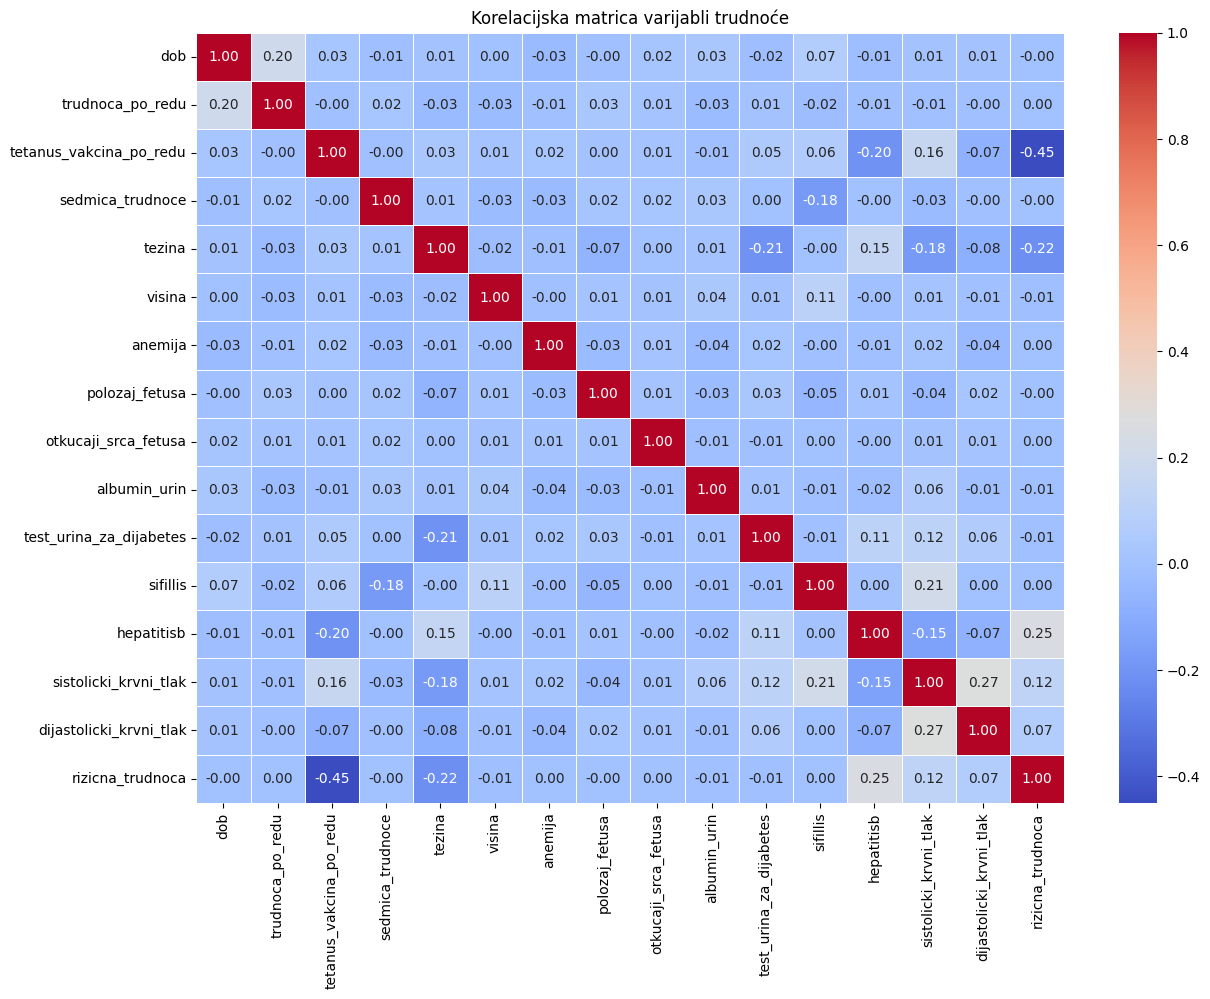

In [185]:
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Korelacijska matrica varijabli trudnoće')
plt.show()

p-value

In [186]:
def korelacija_sa_p_vrijednostima(df):
    """
    Računa Pearsonovu korelaciju i p-vrijednosti za već ucitani DataFrame.
    
    Parametri:
    df : pandas DataFrame - tvoji podaci
    
    Returns:
    corr_df : DataFrame - korelacije
    p_df : DataFrame - p-vrijednosti
    """
    varijable = df.columns
    n = len(varijable)
    
    corr_matrica = np.zeros((n, n))
    p_matrica = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            # Ukloni NaN vrijednosti za svaki par (opciono, ali preporucujem)
            x = df.iloc[:, i].dropna()
            y = df.iloc[:, j].dropna()
            
            # Mora biti ista dužina nakon uklanjanja NaN
            if len(x) != len(df.iloc[:, i]):
                # Ako ima NaN, bolje uraditi zajednicko uklanjanje
                mask = df.iloc[:, [i, j]].dropna().index
                x = df.iloc[mask, i]
                y = df.iloc[mask, j]
            
            r, p = pearsonr(x, y)
            corr_matrica[i, j] = r
            p_matrica[i, j] = p
    
    corr_df = pd.DataFrame(corr_matrica, index=varijable, columns=varijable)
    p_df = pd.DataFrame(p_matrica, index=varijable, columns=varijable)
    
    return corr_df, p_df


# -------------------------------------------------------------------
# KORIŠTENJE (na tvom već učitanom DataFrame-u)
# -------------------------------------------------------------------

# Pokreni funkciju na tvom datasetu
korelacije, p_vrijednosti = korelacija_sa_p_vrijednostima(df)

# Prikaži rezultate
print("\n=== KORELACIJSKA MATRICA ===\n")
print(korelacije.round(4))

print("\n=== P-VRIJEDNOSTI ===\n")
print(p_vrijednosti.round(4))

# -------------------------------------------------------------------
# Prikaži samo statistički značajne korelacije (p < 0.05)
# -------------------------------------------------------------------
print("\n=== ZNAČAJNE KORELACIJE (p < 0.05) ===\n")
znacajne = []
for i in range(len(korelacije.columns)):
    for j in range(i+1, len(korelacije.columns)):
        if p_vrijednosti.iloc[i, j] < 0.05:
            znacajne.append((korelacije.columns[i], 
                            korelacije.columns[j], 
                            korelacije.iloc[i, j], 
                            p_vrijednosti.iloc[i, j]))

if znacajne:
    for v1, v2, r, p in znacajne:
        print(f"{v1} — {v2}: r = {r:.4f}, p = {p:.4f}")
else:
    print("Nema statistički značajnih korelacija na nivou p < 0.05")



=== KORELACIJSKA MATRICA ===

                            dob  trudnoca_po_redu  tetanus_vakcina_po_redu  \
dob                      1.0000            0.1968                   0.0256   
trudnoca_po_redu         0.1968            1.0000                  -0.0033   
tetanus_vakcina_po_redu  0.0256           -0.0033                   1.0000   
sedmica_trudnoce        -0.0098            0.0205                  -0.0028   
tezina                   0.0055           -0.0348                   0.0268   
visina                   0.0018           -0.0276                   0.0104   
anemija                 -0.0329           -0.0080                   0.0242   
polozaj_fetusa          -0.0028            0.0337                   0.0049   
otkucaji_srca_fetusa     0.0172            0.0136                   0.0090   
albumin_urin             0.0267           -0.0275                  -0.0093   
test_urina_za_dijabetes -0.0181            0.0081                   0.0511   
sifillis                 0.0671  

This dataset is not suitable for training a predictive model because most variables have extremely low correlations with the target variable rizicna_trudnoca (e.g., age r = -0.001, anemia r = 0.001), meaning they barely explain pregnancy risk. Although some individual statistically significant correlations exist (e.g., tetanus vaccine and risk), they are too weak to build a reliable application for clinical use. Using such a dataset would result in a model with very low predictive power and potentially dangerous incorrect conclusions.

Ovaj dataset nije prikladan za treniranje prediktivnog modela jer većina varijabli ima izrazito nisku korelaciju s ciljnom varijablom rizicna_trudnoca (npr. dob r = -0.001, anemija r = 0.001), što znači da gotovo ne objašnjavaju rizik trudnoće. Iako postoje pojedinačne statistički značajne korelacije (npr. tetanus vakcina i rizik), one su preslabe da bi se na njima gradila pouzdana aplikacija za kliničku upotrebu. Korištenje ovakvog skupa podataka dovelo bi do modela s vrlo niskom prediktivnom moći i potencijalno opasnih pogrešnih zaključaka.Ovaj dataset nije prikladan za treniranje prediktivnog modela jer većina varijabli ima izrazito nisku korelaciju s ciljnom varijablom rizicna_trudnoca (npr. dob r = -0.001, anemija r = 0.001), što znači da gotovo ne objašnjavaju rizik trudnoće. Iako postoje pojedinačne statistički značajne korelacije (npr. tetanus vakcina i rizik), one su preslabe da bi se na njima gradila pouzdana aplikacija za kliničku upotrebu. Korištenje ovakvog skupa podataka dovelo bi do modela s vrlo niskom prediktivnom moći i potencijalno opasnih pogrešnih zaključaka.